In [1]:
from DatascienceAllFunctions import DsFunctions as dsf
## Reading the data from CSV file
dataset=dsf.importDataset()

#### 1.2 1)Replace the NaN values with correct value. And justify why you have #chosen the same.

In [2]:
dataset.isnull().sum()

sl_no              0
gender             0
ssc_p              0
ssc_b              0
hsc_p              0
hsc_b              0
hsc_s              0
degree_p           0
degree_t           0
workex             0
etest_p            0
specialisation     0
mba_p              0
status             0
salary            67
dtype: int64

In [3]:
## Only Salary is having NAN Values
## The candidate whos is not placed is having Salary as NAN.
## Justification: Replacing NAN with 0 will not affect the dataset

In [4]:
## Replacing Salary with 0 where NAN values are present
dataset.fillna({'salary': 0},inplace=True)

In [5]:
#3 Recheck dataset for NAN
dataset.isnull().sum()

sl_no             0
gender            0
ssc_p             0
ssc_b             0
hsc_p             0
hsc_b             0
hsc_s             0
degree_p          0
degree_t          0
workex            0
etest_p           0
specialisation    0
mba_p             0
status            0
salary            0
dtype: int64

#### 1.3 2)How many of them are not placed?

In [6]:
notPlaced=(dataset['status'] == 'Not Placed').sum().item()
notPlaced

67

In [7]:
## Totally there are 67 persons not placed

#### 1.4 3)Find the reason for non placement from the dataset?

In [8]:
dataset.drop(columns=['sl_no'], inplace=True,axis=1) # since this column has no impact removed it from Dataset

In [9]:
quan, qual = dsf.quanQual(dataset)

In [10]:
descriptive = dsf.findUnivariate(dataset,quan)


In [11]:
descriptive

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
Mean,67.303395,66.333163,66.370186,72.100558,62.278186,198702.325581
Median,67.0,65.0,66.0,71.0,62.0,240000.0
Mode,62.0,63.0,65.0,60.0,56.7,0.0
Q1:25%,60.6,60.9,61.0,60.0,57.945,0.0
Q2:50%,67.0,65.0,66.0,71.0,62.0,240000.0
Q3:75%,75.7,73.0,72.0,83.5,66.255,282500.0
Q4:100%,89.4,97.7,91.0,98.0,77.89,940000.0
IQR,15.1,12.1,11.0,23.5,8.31,282500.0
1.5rule,22.65,18.15,16.5,35.25,12.465,423750.0
LowerIQR,37.95,42.75,44.5,24.75,45.48,-423750.0


In [12]:
descriptive = dsf.checkforOutliers(descriptive,quan)

In [13]:
lower=[]
higher=[]
dataset=dsf.replaceOutliersWithIQRValues(dataset,descriptive,lower,higher)

In [14]:
### Not sure on how to arrive a conclusion. Need assistance

#### 1.5 4)What kind of relation between salary and mba_p

In [15]:
## Since the question is talking about Relationship we use Correlation
dataset[quan].corr()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.538090
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.452569
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,0.408371
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.186988
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.139823
salary,0.538090,0.452569,0.408371,0.186988,0.139823,1.000000


In [16]:
## From the above table we can infere that relation between salary and mba_p is a positive correlation of 0.139823

#### 1.6 5)Which specialization is getting minimum salary?

In [17]:
dataset.groupby('specialisation')['salary'].describe()

,count,mean,std,min,25%,50%,75%,max
specialisation,,,,,,,,
Mkt&Fin,120.0,236591.666667,155242.802284,0.0,210000.0,250000.0,300000.0,940000.0
Mkt&HR,95.0,150842.105263,141007.342180,0.0,0.0,210000.0,260000.0,450000.0


In [18]:
## From the above table we can infere that Mkt&HR is getting less Salary than Mkt&Fin

#### 1.7 6)How many of them getting above 500000 salary?

In [19]:
dataset[dataset['salary'] > 500000].shape[0]

3

#### 1.8 7)Test the Analysis of Variance between etest_p and mba_p at signifance level 5%.(Make decision using Hypothesis Testing)

In [20]:
# H0 (Null Hypothesis): There is no significant difference between etest_p and mba_p
# H1 (Alternate Hypothesis): There is a significant difference between etest_p and mba_p

## We can use One way ANOVA
from scipy import stats
p_value = stats.f_oneway(dataset['etest_p'], dataset['mba_p'])

In [21]:
p_value

F_onewayResult(statistic=np.float64(98.64487057324708), pvalue=np.float64(4.672547689133573e-21))

In [22]:
## From the above tests we identified pvalue is greater than 0.05%
## Conclusion: We reject null hypothesis and proceed with Alternative Hypothesis
## There is a significant difference between etest_p and mba_p

#### 1.9 8)Test the similarity between the degree_t(Sci&Tech) and specialisation(Mkt&HR) with respect to salary

In [23]:
## Hypothesis testing

# H₀ (Null Hypothesis): There is no significant difference in salary between students with degree_t = Sci&Tech and specialisation = Mkt&HR
# H₁ (Alternate Hypothesis): There is a significant difference in salary
#Significance level (α) = 0.05

In [24]:
## Paired T test
## Same Group #different condition 

from scipy.stats import ttest_ind

salary_sci_tech = dataset[dataset['degree_t'] == 'Sci&Tech']['salary']
salary_mkt_hr = dataset[dataset['specialisation'] == 'Mkt&HR']['salary']
t_stat,p_value=ttest_ind(salary_sci_tech, salary_mkt_hr)
print("P-value:", p_value)

P-value: 0.007897969943471179


In [25]:
## Based on the above tests, pvalue is less than 0.5%
## Conclusion: We can Proceed with null hypothesis

#### 1.10 9)Convert the normal distribution to standard normal distribution for salary column

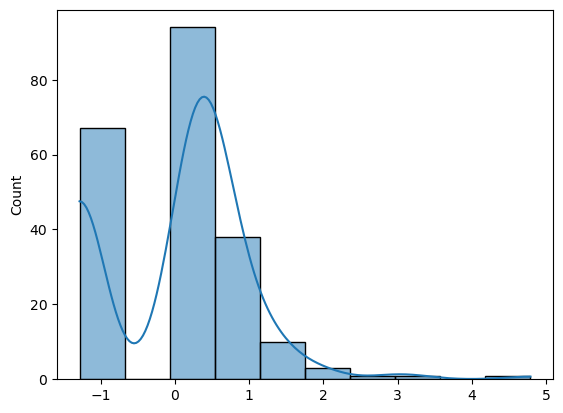

In [26]:
z_score=dsf.stdNBgraph(dataset["salary"])

#### 1.11 10)What is the probability Density Function of the salary range from 700000 to 900000?

C:\AI Learnings\5.DataScience\AssignmentDataScience\DatascienceAllFunctions.py:99: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


Mean=198702.326, Standard Deviation=154780.927
The area between range(70000,90000):0.038404601457347344


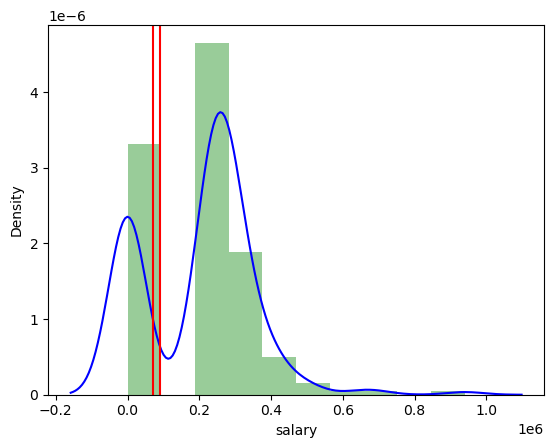

In [27]:
probablility=dsf.get_pdf_probability(dataset["salary"],70000,90000)

In [28]:
## From the above graph we can concule the PDF is 0.03%

#### 1.12 11)Test the similarity between the degree_t(Sci&Tech)with respect to etest_p and mba_p at significance level of 5%.
#### (Make decision using Hypothesis Testing)

In [29]:
# H₀ (Null Hypothesis):There is no significant difference between etest_p and mba_p scores for Sci&Tech students.
# H₁ (Alternate Hypothesis):There is a significant difference between the two scores.

In [30]:
## USe ANOVA in this case


sci_tech = dataset[dataset['degree_t'] == 'Sci&Tech']
result = stats.f_oneway(sci_tech['etest_p'],sci_tech['mba_p'])
p_value = result.pvalue
p_value

np.float64(1.4289217003775155e-05)

In [31]:
## Basesd on the above result p_value is significantly greater than 0.05
## Conclusion Reject null Hypothesis and proceed with Alternate Hypothesis

#### 1.13 12)Which parameter is highly correlated with salary?

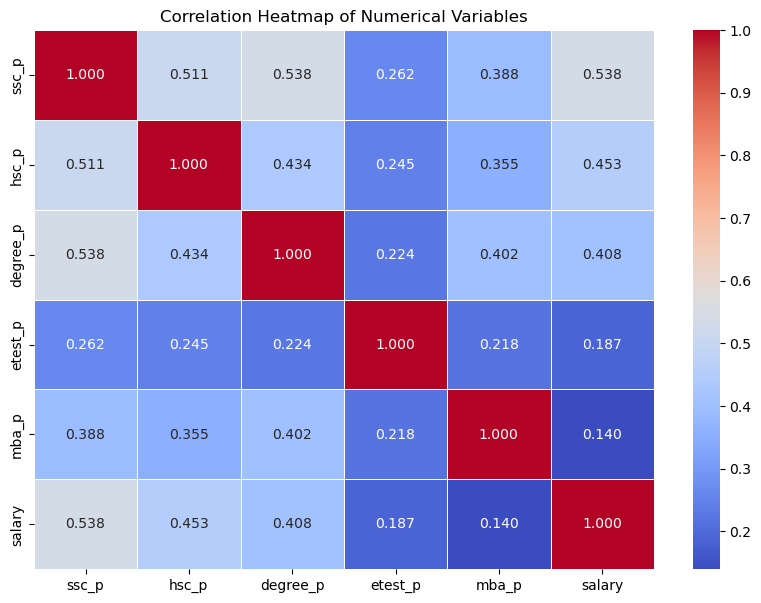

In [32]:
## Got this code from Internet which helps in uderstanding the correlation chart
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

data = dataset.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = data.corr()

# Plot heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".3f",linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [33]:
# Compute correlation with salary
corr_salary = dataset.corr(numeric_only=True)['salary']

# Sort correlations in Ascending order
corr_salary_sort = corr_salary.sort_values(ascending=True)

print(corr_salary_sort)


mba_p       0.139823
etest_p     0.186988
degree_p    0.408371
hsc_p       0.452569
ssc_p       0.538090
salary      1.000000
Name: salary, dtype: float64


In [34]:
## Based on the above test results , It shows ssc_p has high correlation with Salary

#### 1.14 13) plot any useful graph and explain it.

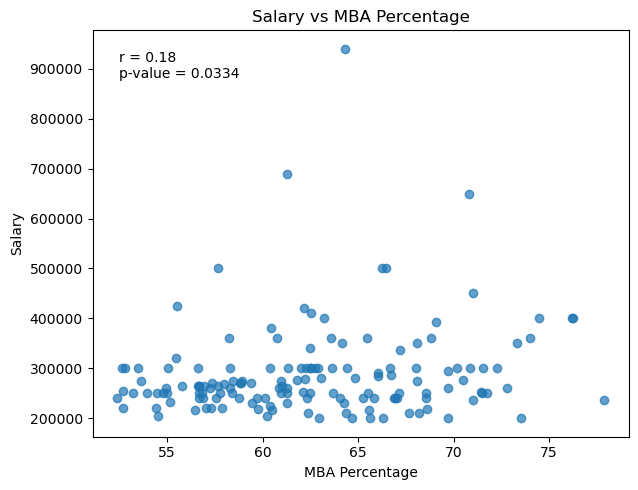

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Use only placed students
placed_data = dataset[dataset['salary'] > 0]

# Calculate correlation and p-values

r_mba, p_mba = pearsonr(placed_data['mba_p'], placed_data['salary'])

# Create subplots
plt.figure(figsize=(12, 5))

# Salary vs MBA %
plt.subplot(1, 2, 2)
plt.scatter(placed_data['mba_p'], placed_data['salary'], alpha=0.7)
plt.xlabel("MBA Percentage")
plt.ylabel("Salary")
plt.title("Salary vs MBA Percentage")

plt.text(0.05, 0.95,f"r = {r_mba:.2f}\np-value = {p_mba:.4f}",transform=plt.gca().transAxes,fontsize=10,
         verticalalignment='top')

plt.tight_layout()
plt.show()


In [36]:
## Created this graph to understand the MBA % vs salary. whether MBA% can have impact on  Salary